In [1]:
import numpy as np
import glob
import re
import scipy.stats as stats
from scipy.optimize import minimize
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# for colors on plots
from colormath.color_objects import LabColor, sRGBColor
from colormath.color_conversions import convert_color

In [2]:
# High-level variables

# Conditions
POSITIONS = [3, 7, 11, 15] # positions of high-payoff objects
N_POS = len(POSITIONS)
SET_SIZES = [2, 5, 8] # memory set sizes
N_SS = len(SET_SIZES)
SUBJECTS = range(1, 9) # subject IDs (1-8), we'll use it later
N_ITEMS = 16 # total number of items in the experiment

# Integration in TCC
N_POINTS = 500
X_RANGE = (-3, 10)

# Fit only one subject for now (for class project)
FIT_SUBJECTS = [4]

# Should use single MDS solution for all subjects (perfect circle)?
USE_SINGLE_MDS_SOLUTION = True

# Read data

Data will be a dictionary:
- Subject (1, 2, 3...)
    - Raw individual or aggregated across positions data
        - set size
            - position
                - 16 x 16 matrix with data

In [3]:
data_folder = 'Data' # folder containing the subject files

def parse_subject_file(filepath):
    with open(filepath, 'r') as f:
        content = f.read()

    blocks = re.split(r'\n{2,}', content.strip())

    matrices = []
    for block in blocks:
        lines = [l.strip() for l in block.strip().splitlines() if l.strip()]
        if not lines:
            continue
        rows = []
        for line in lines:
            values = list(map(int, line.split()))
            rows.append(values[1:])
        mat = np.array(rows)
        if mat.shape == (16, 16):
            matrices.append(mat)
    return matrices

data = {}
for filepath in sorted(glob.glob(f'{data_folder}/coloridentification_s*.txt')):
    subject_id = int(re.search(r's(\d+)\.txt', filepath).group(1))
    matrices = parse_subject_file(filepath)

    # Build individual: nested dict ss -> pos
    individual = {}
    for j, ss in enumerate(SET_SIZES):
        individual[ss] = {}  # create inner dict for this set size
        for i, pos in enumerate(POSITIONS):
            idx = j * len(POSITIONS) + i
            individual[ss][pos] = {}
            individual[ss][pos]['data'] = matrices[idx]

    # Build aggregated: last 3 matrices, one per set size
    aggregated = {}
    for j, ss in enumerate(SET_SIZES):
        aggregated[ss] = matrices[12 + j]

    data[subject_id] = {
        'individual': individual,   # keyed by (position, set_size)
        'aggregated': aggregated,   # keyed by set_size
    }

# Save
# with open(f'{data_folder}/coloridentification_all.pkl', 'wb') as f:
#     pickle.dump(data, f)

In [4]:
# Fitting models only to subject 4 for now (for class project)
if FIT_SUBJECTS is not None:
    SUBJECTS = FIT_SUBJECTS

# MDS-solution

In [5]:
# Extract observed data and store it in a structured format for model fitting 
# (matrix of shape (C, 16, 16) where C is the number of conditions)
def extract_observed(data, SUBJECTS, SET_SIZES, POSITIONS):
    observed = []
    all_conditions = []

    for subj in SUBJECTS:
        for ss in SET_SIZES:
            for pos in POSITIONS:
                mat = data[subj]['individual'][ss][pos]['data']

                observed.append(mat)
                all_conditions.append((subj, ss, pos))

    observed = np.array(observed)  # (C,16,16)

    return observed, all_conditions

# save data in a structured format for model fitting
data_structured = extract_observed(data, SUBJECTS=SUBJECTS, SET_SIZES=SET_SIZES, POSITIONS=POSITIONS)
data_matrix = data_structured[0]  # (C,16,16)

*data_matrix* format:

--- SUBJECT 1 ---
- set size 2:
    - position 3
    - position 7
    - position 11
    - position 15
- set size 5:
    - position 3
    - position 7
    - position 11
    - position 15
- set size 8:
    - position 3
    - position 7
    - position 11
    - position 15

--- SUBJECT 2 ---

...

--- SUBJECT 8 ---

In [6]:
# Read MSD solutions

if USE_SINGLE_MDS_SOLUTION:
    r = 1 # radius of the circle
    angles = np.linspace(np.pi/2, np.pi/2 - 2*np.pi, N_ITEMS, endpoint=False)
    x = r * np.cos(angles)
    y = r * np.sin(angles)

    MDS_COORDS = np.column_stack((x, y))

    # Save a single MDS solution for all conditions
    for subj in SUBJECTS:
        for ss in SET_SIZES:
            for pos in POSITIONS:
                data[subj]['individual'][ss][pos]['mds_coords'] = MDS_COORDS
# Below needs correction
else: # Use subject-specific MDS solutions and weights (from previous analyses)
    # Read saved MDS-solution and weights
    mds_solution = pd.read_csv('MDS_results/stimulus_coordinates.csv')
    mds_weights = pd.read_csv('MDS_results/subject_weights.csv')

    # Get coordinates for EACH subject
    coords = mds_solution.loc[:, 'dim1':'dim2']
    for subj in SUBJECTS:
        for ss in SET_SIZES:
            for pos in POSITIONS:
                weights = mds_weights.loc[(mds_weights['subject'] == subj) & 
                                        (mds_weights['set_size'] == ss) & 
                                        (mds_weights['position'] == pos), 
                                        'dim1':'dim2'].values
                current_coords = coords * weights
                data[subj]['individual'][ss][pos]['mds_coords'] = current_coords
  

In [7]:
# Compute distances (Euclidean) for each subject, set size, and position
for subj in SUBJECTS:
    for ss in SET_SIZES:
        for pos in POSITIONS:
            mds_coords = data[subj]['individual'][ss][pos]['mds_coords']
            # mds_coords = mds_coords.to_numpy() # may use it if mds_coords is a DataFrame
            distances = np.linalg.norm(mds_coords[:, None, :] - mds_coords[None, :, :], axis=-1)
            data[subj]['individual'][ss][pos]['mds_distances'] = distances

# Models

In [8]:
# Prepare data for model fitting: 
# extract MDS distances, counts, positions, and set size indices into arrays
def prepare_data(data, SUBJECTS, SET_SIZES, POSITIONS):
    all_conditions = []
    distances      = []
    counts         = []
    pos_array      = []
    ss_idx         = []

    for subj in SUBJECTS:
        for i_ss, ss in enumerate(SET_SIZES):
            for pos in POSITIONS:
                all_conditions.append((subj, ss, pos))
                distances.append(data[subj]['individual'][ss][pos]['mds_distances'])
                counts.append(data[subj]['individual'][ss][pos]['data'].sum(axis=1, keepdims=True))
                pos_array.append(pos - 1)
                ss_idx.append(i_ss)

    distances = np.array(distances)  # (C,16,16)
    counts    = np.array(counts)     # (C,16,1)
    pos_array = np.array(pos_array)  # (C,)
    ss_idx    = np.array(ss_idx)     # (C,)

    return distances, counts, pos_array, ss_idx, all_conditions

prepared_data = prepare_data(data, SUBJECTS, SET_SIZES, POSITIONS)

## SCM

Parameters: 

- c (sensitivity) is set-size specific (3 pars)

- For 16 objects - 15 free parameters, last one is determined $1-\sum_1^{15} b_j$

- B - for high-payoff colors: single parameter for the whole data set

**Total** = 3 + (15+1) + 1 = 19 free parameters (20 total parameters)

In [9]:
def unpack_SCM_params(params_vec):
    n_bias_params = N_ITEMS - 1

    bias_params = params_vec[:n_bias_params]                              # (15,)
    B           = params_vec[n_bias_params]                               # scalar
    c_params    = params_vec[n_bias_params+1:n_bias_params+1+N_SS]  # (3,)

    last_bias = 1 - bias_params.sum()
    biases    = np.append(bias_params, last_bias)                         # (16,)

    return biases, B, c_params

In [10]:
def SCM(params_vec, prepared_data=prepared_data):
    distances, counts, pos_array, ss_idx, _ = prepared_data

    biases, B, c_params = unpack_SCM_params(params_vec)

    C = len(ss_idx)  # all subjects × conditions

    bias_per_condition = np.tile(biases, (C, 1))                          # (C, 16)
    boost_matrix = np.ones_like(bias_per_condition)
    boost_matrix[np.arange(C), pos_array] = B
    bias_per_condition = bias_per_condition * boost_matrix
    bias_per_condition = bias_per_condition / bias_per_condition.sum(axis=1, keepdims=True)

    c_per_condition = c_params[ss_idx][:, None, None]                     # (C, 1, 1)
    sim  = np.exp(-c_per_condition * distances)                           # (C, 16, 16)
    num  = sim * bias_per_condition[:, None, :]                           # (C, 16, 16)
    prob = num / num.sum(axis=2, keepdims=True)

    pred_counts = counts * prob
    return prob, pred_counts

## SCM-mix

Parameters: 

- c (sensitivity) is set-size specific (3 pars)

- For 16 objects - 15 free parameters, last one is determined $1-\sum_1^{15} b_j$

- B - for high-payoff colors: single parameter for the whole data set

- Gamma: single for the whole data set (values make sense between 0.5 and 3):
    - Gamma < 1 flattens the guessing distribution (more uniform), 
    - Gamma > 1 sharpens it (higher bias items get more weight)

- p_mem: probability that an object is remembered. Set-size specific: 3 params

**Total** = 3 + (15+1) + 1 + 3 = 23 free parameters (24 total parameters)

Here also add mixture model: guessing state (1 par or set size specific - 3 params)

In [11]:
def unpack_SCM_mix_params(params_vec): 
    bias_params   = params_vec[:N_ITEMS-1]                            # (15,)
    last_bias     = 1 - bias_params.sum()
    biases        = np.append(bias_params, last_bias)                 # (16,)
    B             = params_vec[N_ITEMS-1]                             # scalar
    c_params      = params_vec[N_ITEMS:N_ITEMS+N_SS]                  # (3,)
    memory_params = params_vec[N_ITEMS+N_SS:N_ITEMS+N_SS*2]          # (3,)
    gamma         = params_vec[N_ITEMS+N_SS*2]                        # scalar

    return biases, B, c_params, memory_params, gamma

In [12]:
def SCM_mix(params_vec, prepared_data=prepared_data):
    
    distances, counts, pos_array, ss_idx, _ = prepared_data
    biases, B, c_params, memory_params, gamma = unpack_SCM_mix_params(params_vec)

    C = len(ss_idx)

    bias_per_condition = np.tile(biases, (C, 1))                          # (C, 16)
    boost_matrix = np.ones_like(bias_per_condition)
    boost_matrix[np.arange(C), pos_array] = B
    bias_per_condition = bias_per_condition * boost_matrix
    bias_per_condition = bias_per_condition / bias_per_condition.sum(axis=1, keepdims=True)

    c_per_condition      = c_params[ss_idx][:, None, None]                # (C, 1, 1)
    sim  = np.exp(-c_per_condition * distances)                           # (C, 16, 16)
    num  = sim * bias_per_condition[:, None, :]                           # (C, 16, 16)
    p_ij = num / num.sum(axis=2, keepdims=True)                           # (C, 16, 16)

    g_j_raw = bias_per_condition ** gamma                                  # (C, 16)
    g_j     = g_j_raw / g_j_raw.sum(axis=1, keepdims=True)                # (C, 16)
    g_j     = g_j[:, None, :]                                              # (C, 1, 16)

    memory_per_condition = memory_params[ss_idx][:, None, None]           # (C, 1, 1)
    prob = memory_per_condition * p_ij + (1 - memory_per_condition) * g_j

    pred_counts = counts * prob
    return prob, pred_counts

## TCC

Parameters:

- d': 16 d's for each object, shared across conditions

- c: 1 similarity function, shared across all conditions

- high-payoff boost: a single value that is added to d' of high-payoff color

- space shrinkage: 
    - intercept: 2, for ss-5 and ss-8
    - slope: 2, for ss-5 and ss-8
    - they indicate how the memory (d') space is shrunk in set-size-5 and -8 conditions, compared to set size 2

**Total:** 16 + 1 + 1 + (2+2) = 22 free parameters

In [13]:
# Compute probabilities
# fam_distr_mu_ij - array of shape (C, 16, 16) containing the mean of the familiarity distribution for each item in each condition
def compute_pred_probs_TCC(fam_distr_mu_ij, n_points=N_POINTS, x_range=X_RANGE):
    # handle both 2D and 3D input
    squeeze = fam_distr_mu_ij.ndim == 2
    if squeeze:
        fam_distr_mu_ij = fam_distr_mu_ij[None, :, :]  # (1, 16, 16)

    x_grid = np.linspace(x_range[0], x_range[1], n_points)
    dx     = x_grid[1] - x_grid[0]

    fam_exp = fam_distr_mu_ij[:, :, :, None]         # (C, 16, 16, 1)
    x_exp   = x_grid[None, None, None, :]        # (1,  1,  1,  n_points)

    cdfs            = stats.norm.cdf(x_exp, loc=fam_exp)   # (C, 16, 16, n_points)
    log_cdfs        = np.log(np.clip(cdfs, 1e-300, 1))
    log_prod_all    = log_cdfs.sum(axis=2, keepdims=True)   # (C, 16, 1,  n_points)
    log_prod_excl_j = log_prod_all - log_cdfs               # (C, 16, 16, n_points)
    prod_excl_j     = np.exp(log_prod_excl_j)
    pdf_j           = stats.norm.pdf(x_exp, loc=fam_exp)

    pred_probs = np.sum(pdf_j * prod_excl_j * dx, axis=3)  # (C, 16, 16)

    return pred_probs[0] if squeeze else pred_probs

In [14]:
def unpack_TCC_params(params_vec):   
    d_prime_base = params_vec[0]                                        # scalar
    d_scales     = np.concatenate([[1.0], params_vec[1:N_SS]])          # (3,) ss=2 fixed at 1
    c            = params_vec[N_SS]                                     # scalar
    biases       = params_vec[N_SS+1:N_SS+1+N_ITEMS]                   # (16,) all free
    hp_boost     = params_vec[N_SS+1+N_ITEMS]                          # scalar

    return d_prime_base, d_scales, c, biases, hp_boost

In [15]:
def TCC(params_vec,
        prepared_data=prepared_data,
        n_points=N_POINTS, x_range=X_RANGE):

    distances, counts, pos_array, ss_idx, _ = prepared_data

    d_prime_base, d_scales, c, biases, hp_boost = unpack_TCC_params(params_vec)

    C = len(ss_idx)

    d_scales_per_cond = d_scales[ss_idx]                                   # (C,)
    d_prime_per_cond  = d_prime_base * d_scales_per_cond                   # (C,)

    sim   = np.exp(-c * distances)                                         # (C, 16, 16)
    mu_ij = d_prime_per_cond[:, None, None] * sim + biases[None, None, :] # (C, 16, 16)
    mu_ij[np.arange(C), :, pos_array] += hp_boost

    pred_probs  = compute_pred_probs_TCC(mu_ij, n_points, x_range)        # (C, 16, 16)
    pred_counts = counts * pred_probs
    return pred_probs, pred_counts

## TCC-mix

In [16]:
def unpack_TCC_mix_params(params_vec):
    d_prime_base = params_vec[0]                                           # scalar
    d_scales     = np.concatenate([[1.0], params_vec[1:N_SS]])             # (3,)
    c            = params_vec[N_SS]                                        # scalar
    biases       = params_vec[N_SS+1:N_SS+1+N_ITEMS]                      # (16,)
    hp_boost     = params_vec[N_SS+1+N_ITEMS]                             # scalar
    p_mem        = params_vec[N_SS+2+N_ITEMS:N_SS+2+N_ITEMS+N_SS]         # (3,)
    gamma        = params_vec[N_SS+2+N_ITEMS+N_SS]                        # scalar

    return d_prime_base, d_scales, c, biases, hp_boost, p_mem, gamma

In [17]:
def TCC_mix(params_vec,
            prepared_data=prepared_data,
            n_points=N_POINTS, x_range=X_RANGE):

    distances, counts, pos_array, ss_idx, _ = prepared_data

    d_prime_base, d_scales, c, biases, hp_boost, p_mem, gamma = unpack_TCC_mix_params(params_vec)

    C = len(ss_idx)

    d_scales_per_cond = d_scales[ss_idx]
    d_prime_per_cond  = d_prime_base * d_scales_per_cond

    sim   = np.exp(-c * distances)                                         # (C, 16, 16)
    mu_ij = d_prime_per_cond[:, None, None] * sim + biases[None, None, :] # (C, 16, 16)
    mu_ij[np.arange(C), :, pos_array] += hp_boost

    p_tcc = compute_pred_probs_TCC(mu_ij, n_points, x_range)              # (C, 16, 16)

    biases_boosted = np.tile(biases, (C, 1))                               # (C, 16)
    biases_boosted[np.arange(C), pos_array] += hp_boost
    # apply softmax to get bias-based probabilities
    bias_probs = np.exp(biases_boosted)
    bias_probs = bias_probs / bias_probs.sum(axis=1, keepdims=True)
    g_j_raw    = bias_probs ** gamma
    g_j        = g_j_raw / g_j_raw.sum(axis=1, keepdims=True)
    g_j_exp    = g_j[:, None, :]                                           # (C, 1, 16)

    p_mem_per_cond    = p_mem[ss_idx][:, None, None]                      # (C, 1, 1)
    pred_probs_unique = p_mem_per_cond * p_tcc + (1 - p_mem_per_cond) * g_j_exp

    pred_counts = counts * pred_probs_unique
    return pred_probs_unique, pred_counts

# Optimization

## Set-up

In [18]:
total_counts = data_matrix.sum()

def validity_checks(params, model):
    # ----- SCM -----
    if model is SCM:
        biases, _, _ = unpack_SCM_params(params)
        if np.any(biases <= 0):
            return False
    
    # ---- SCM_mix -----  
    elif model is SCM_mix:
        biases, _, _, memory_params, gamma = unpack_SCM_mix_params(params)
        if (np.any(biases <= 0) or 
            np.any(memory_params < 0) or 
            np.any(memory_params > 1) or 
            gamma < 0):
            return False
    
    # ---- TCC ----
    elif model is TCC:
        return True
    
    # ---- TCC-mix ----
    elif model is TCC_mix:
        _, _, _, biases, hp_boost, p_mem, gamma = unpack_TCC_mix_params(params)
        if (np.any(p_mem < 0) or 
            np.any(p_mem > 1) or 
            gamma < 0 or 
            hp_boost < 0):
            return False
    
    # ---- Unknown model ----
    else:
        return False
    
    return True

In [19]:
# Negative log-likelihood (NLL)
def neg_log_likelihood(params, model, 
                       observed_counts, prep_data,
                       n_points = N_POINTS, x_range=X_RANGE):
    if not validity_checks(params, model):
        return 1e10

    if model is SCM or model is SCM_mix:
        predicted_probs = model(params_vec=params, prepared_data=prep_data)[0]
    
    elif model is TCC or model is TCC_mix:
        predicted_probs = model(params_vec=params, prepared_data=prep_data,
                                n_points=n_points, x_range=x_range)[0]

    eps = 1e-12
    return -np.sum(observed_counts * np.log(predicted_probs + eps)) / total_counts

In [20]:
def fit_model(loss_func, 
              initial_params, params_bounds, model, 
              observed_counts, prep_data, 
              n_points=N_POINTS, x_range=X_RANGE,
              warmup_options=None, final_options=None, print_every=10):
    
    # Optimizer options
    if warmup_options is None:
        warmup_options = {'ftol': 1e-9, 'gtol': 1e-3, 'maxiter': 1000, 'maxfun': 10000}
    if final_options is None:
        final_options = {'ftol': 1e-9, 'gtol': 1e-3, 'maxiter': 10000, 'maxfun': 100000}

    # Track progress
    def make_callback(stage):
        iterations = [0]
        def callback(x):
            iterations[0] += 1
            if iterations[0] % print_every == 0:
                if model is TCC or model is TCC_mix:
                    loss = loss_func(x, model, observed_counts, prep_data,
                                      n_points=n_points, x_range=x_range)
                else:
                    loss = loss_func(x, model, observed_counts, prep_data)
                print(f"  [{stage}] Iteration {iterations[0]:4d}: loss = {loss:.6f}")
        return callback

    # Set up arguments for NLL
    if model is SCM or model is SCM_mix:
        args_tuple = (model, observed_counts, prep_data)
    elif model is TCC or model is TCC_mix:
        args_tuple = (model, observed_counts, prep_data, n_points, x_range)
    
    # Warm up
    print("=== Warmup ===")
    fit_warmup = minimize(
        loss_func, initial_params,
        args=args_tuple,
        bounds=params_bounds, method='L-BFGS-B',
        callback=make_callback('warmup'),
        options=warmup_options
    )
    print(f"Warmup done: {fit_warmup.message} | Loss: {fit_warmup.fun:.6f}\n")

    # Final fit
    print("=== Final fit ===")
    fit_final = minimize(
        loss_func, fit_warmup.x,
        args=args_tuple,
        bounds=params_bounds, method='L-BFGS-B',
        callback=make_callback('final'),
        options=final_options
    )
    print(f"Final done:  {fit_final.message} | Loss: {fit_final.fun:.6f}")

    return fit_final

## Running 

In mixture models use optimal parameters from their counterparts for warm-up

### SCM

In [21]:
initial_params_SCM = np.concatenate([
    np.repeat(1/16, 15),    # biases: start neutral
    np.array([1.0]),        # boost parameter B: start neutral
    np.repeat(0.01, 3)      # c
])
bounds_SCM = (
    [(0, 1)] * 15 +         # biases in [0, 1]
    [(0, None)] +           # boost parameter B >= 0
    [(0, None)] * 3         # c >= 0
    )
SCM_fit = fit_model(loss_func=neg_log_likelihood,
                    initial_params=initial_params_SCM,
                    params_bounds=bounds_SCM,
                    model=SCM,
                    observed_counts=data_matrix,
                    prep_data=prepared_data)

=== Warmup ===
  [warmup] Iteration   10: loss = 2.248934
  [warmup] Iteration   20: loss = 1.480478
  [warmup] Iteration   30: loss = 1.466366
  [warmup] Iteration   40: loss = 1.387611
  [warmup] Iteration   50: loss = 1.382254
  [warmup] Iteration   60: loss = 1.367486
  [warmup] Iteration   70: loss = 1.366782
  [warmup] Iteration   80: loss = 1.362982
  [warmup] Iteration   90: loss = 1.359705
  [warmup] Iteration  100: loss = 1.356106
  [warmup] Iteration  110: loss = 1.351791
  [warmup] Iteration  120: loss = 1.346989
  [warmup] Iteration  130: loss = 1.338664
  [warmup] Iteration  140: loss = 1.338376
  [warmup] Iteration  150: loss = 1.337365
  [warmup] Iteration  160: loss = 1.335520
  [warmup] Iteration  170: loss = 1.334439
  [warmup] Iteration  180: loss = 1.333867
  [warmup] Iteration  190: loss = 1.333695
  [warmup] Iteration  200: loss = 1.333655
Warmup done: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.333654

=== Final fit ===
Final done:  CONVERGENCE: N

In [22]:
# Parameters: 15+1 biases, 1 boost, 3 c params
biases, B, c = unpack_SCM_params(SCM_fit.x)

print("SCM best-fitting parameters:\n")
print(f"Total {len(SCM_fit.x)} free parameters")
print(f"Negative log-likelihood: {SCM_fit.fun:.3f}", end="\n\n")

print("Biases for each item:")
print(biases.round(3), end="\n\n")

print(f"Boost parameter B (for high-payoff items): {B:.3f}", end="\n\n")

print("c parameters (similarity sensitivity) for each set size:")
print(c.round(3))

SCM best-fitting parameters:

Total 19 free parameters
Negative log-likelihood: 1.334

Biases for each item:
[0.035 0.026 0.063 0.051 0.028 0.09  0.082 0.045 0.023 0.057 0.102 0.098
 0.095 0.067 0.079 0.059]

Boost parameter B (for high-payoff items): 14.380

c parameters (similarity sensitivity) for each set size:
[6.734 2.373 1.476]


### SCM-mix

In [23]:
initial_params_SCM_mix = np.concatenate([
    SCM_fit.x[:15],         # biases from SCM solution
    [1.0],                  # boost parameter B: start neutral
    SCM_fit.x[-3:],         # c from SCM solution
    [0.9, 0.8, 0.7],        # prob memory: start high (mostly memory-based)
    [1.0]                   # gamma: neutral
])

bounds_SCM_mix = (
    [(0, 1)]   * 15 +       # biases in [0, 1]
    [(0, None)] * 1  +      # boost parameter B >= 0
    [(0, None)] * 3  +      # c >= 0
    [(0, 1)]   * 3  +       # prob memory in [0, 1]
    [(0, None)] * 1         # gamma >= 0
)

SCM_mix_fit = fit_model(loss_func=neg_log_likelihood,
                        initial_params=initial_params_SCM_mix,
                        params_bounds=bounds_SCM_mix,
                        model=SCM_mix,
                        observed_counts=data_matrix,
                        prep_data=prepared_data)

=== Warmup ===
  [warmup] Iteration   10: loss = 1.522552
  [warmup] Iteration   20: loss = 1.318306
  [warmup] Iteration   30: loss = 1.235958
  [warmup] Iteration   40: loss = 1.230902
  [warmup] Iteration   50: loss = 1.227747
  [warmup] Iteration   60: loss = 1.210118
  [warmup] Iteration   70: loss = 1.208771
  [warmup] Iteration   80: loss = 1.208662
  [warmup] Iteration   90: loss = 1.207571
  [warmup] Iteration  100: loss = 1.207305
  [warmup] Iteration  110: loss = 1.207272
  [warmup] Iteration  120: loss = 1.207204
  [warmup] Iteration  130: loss = 1.207179
  [warmup] Iteration  140: loss = 1.207090
  [warmup] Iteration  150: loss = 1.206842
  [warmup] Iteration  160: loss = 1.206713
Warmup done: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.206711

=== Final fit ===
Final done:  CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.206711


In [24]:
# Parameters: 15+1 biases, 1 boost, 3 c, 3 p_mem, 1 gamma params
biases, B, c, p_mem, gamma = unpack_SCM_mix_params(SCM_mix_fit.x)

print("SCM-mix best-fitting parameters:\n")
print(f"Total {len(SCM_mix_fit.x)} free parameters")
print(f"Negative log-likelihood: {SCM_mix_fit.fun:.3f}", end="\n\n")

print("Biases for each item:")
print(biases.round(3), end="\n\n")

print(f"Boost parameter B (for high-payoff items): {B:.3f}", end="\n\n")

print("c parameters (similarity sensitivity) for each set size:")
print(c.round(3), end="\n\n")

print("Probability of memory parameters for each set size:")
print(p_mem.round(3), end="\n\n")

print(f"Gamma parameter (exponent for bias in guessing): {gamma:.3f}")

SCM-mix best-fitting parameters:

Total 23 free parameters
Negative log-likelihood: 1.207

Biases for each item:
[0.031 0.025 0.078 0.055 0.031 0.096 0.098 0.044 0.018 0.047 0.101 0.089
 0.084 0.061 0.088 0.055]

Boost parameter B (for high-payoff items): 3.693

c parameters (similarity sensitivity) for each set size:
[6.89  4.314 3.904]

Probability of memory parameters for each set size:
[0.985 0.688 0.449]

Gamma parameter (exponent for bias in guessing): 2.555


### TCC

In [25]:
initial_params_TCC = np.concatenate([
    [3.0],                 # d_prime_base
    [0.7, 0.5],            # d_scales for ss=5, ss=8
    [0.01],                # c
    np.repeat(0.0, 16),    # biases — all free, can be negative
    [0.5],                 # hp_boost
])

bounds_TCC = (
    [(0, None)]       +    # d_prime_base >= 0
    [(0, 1)]     * 2  +    # d_scales in [0, 1]
    [(0, None)]       +    # c >= 0
    [(None, None)] * 16 +  # biases unconstrained
    [(0, None)]            # boost >= 0
)

TCC_fit = fit_model(loss_func=neg_log_likelihood,
                    initial_params=initial_params_TCC,
                    params_bounds=bounds_TCC,
                    model=TCC,
                    observed_counts=data_matrix,
                    prep_data=prepared_data,
                    n_points=N_POINTS, x_range=X_RANGE)

=== Warmup ===
  [warmup] Iteration   10: loss = 1.246821
Warmup done: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.237486

=== Final fit ===
Final done:  CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.237486


In [26]:
# Parameters: 1 d_prime_base, 2+1 d_scales, 1 c, 16 biases, 1 hp_boost
d_prime_base, d_scales, c, biases, hp_boost = unpack_TCC_params(TCC_fit.x)

print("TCC best-fitting parameters:\n")
print(f"Total {len(TCC_fit.x)} free parameters")
print(f"Negative log-likelihood: {TCC_fit.fun:.3f}", end="\n\n")

print(f"Base d' (for set size 2): {d_prime_base:.3f}", end="\n\n")

print("d' scales per set size:")
for ss, scale in zip(SET_SIZES, d_scales):
    print(f"  SS={ss}: scale = {scale:.3f}  (d' = {d_prime_base * scale:.3f})")

print(f"\nc parameter (similarity sensitivity): {c:.3f}", end="\n\n")

print(f"Biases for each item:\n{biases.round(3)}", end="\n\n")

print(f"Familiarity boost for high-payoff item: {hp_boost:.3f}")

TCC best-fitting parameters:

Total 21 free parameters
Negative log-likelihood: 1.237

Base d' (for set size 2): 5.186

d' scales per set size:
  SS=2: scale = 1.000  (d' = 5.186)
  SS=5: scale = 0.531  (d' = 2.755)
  SS=8: scale = 0.370  (d' = 1.921)

c parameter (similarity sensitivity): 1.406

Biases for each item:
[-0.323 -0.497  0.161 -0.068 -0.419  0.342  0.322 -0.133 -0.627 -0.026
  0.422  0.285  0.272  0.009  0.266  0.01 ]

Familiarity boost for high-payoff item: 1.638


### TCC-mix

In [27]:
initial_params_TCC_mix = np.concatenate([
    [TCC_fit.x[0]],                # d_prime_base from TCC solution
    TCC_fit.x[1:3],                # d_scales from TCC solution
    [TCC_fit.x[3]],                # c from TCC solution
    TCC_fit.x[4:20],               # biases from TCC solution
    [TCC_fit.x[20]],               # hp_boost from TCC solution
    [0.9, 0.8, 0.7],               # prob memory: start high (mostly memory-based)
    [1.0],                         # gamma
])

bounds_TCC_mix = (
    [(0, None)]       +            # d_prime_base >= 0
    [(0, 1)]     * 2  +            # d_scales in [0, 1]
    [(0, None)]       +            # c >= 0
    [(None, None)] * 16 +          # biases unconstrained
    [(0, None)]       +            # hp_boost >= 0
    [(0, 1)] * 3  +                # prob memory in [0, 1]
    [(0, None)]                    # gamma >= 0
)


TCC_mix_fit = fit_model(loss_func=neg_log_likelihood,
                    initial_params=initial_params_TCC_mix,
                    params_bounds=bounds_TCC_mix,
                    model=TCC_mix,
                    observed_counts=data_matrix,
                    prep_data=prepared_data,
                    n_points=N_POINTS, x_range=X_RANGE)

=== Warmup ===
  [warmup] Iteration   10: loss = 1.235138
  [warmup] Iteration   20: loss = 1.233836
  [warmup] Iteration   30: loss = 1.212507
  [warmup] Iteration   40: loss = 1.209007
  [warmup] Iteration   50: loss = 1.208257
  [warmup] Iteration   60: loss = 1.208152
  [warmup] Iteration   70: loss = 1.208034
Warmup done: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.207966

=== Final fit ===
Final done:  CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL | Loss: 1.207966


In [28]:
d_prime_base, d_scales, c, biases, hp_boost, p_mem, gamma = unpack_TCC_mix_params(TCC_mix_fit.x)

print("TCC-mix best-fitting parameters:\n")
print(f"Total {len(TCC_mix_fit.x)} free parameters")
print(f"Negative log-likelihood: {TCC_mix_fit.fun:.3f}", end="\n\n")

print(f"Base d' (for set size 2): {d_prime_base:.3f}", end="\n\n")

print("d' scales per set size:")
for ss, scale in zip(SET_SIZES, d_scales):
    print(f"  SS={ss}: scale = {scale:.3f}  (d' = {d_prime_base * scale:.3f})")

print(f"c parameter (similarity sensitivity): {c:.3f}", end="\n\n")

print(f"Biases for each item:\n{biases.round(3)}", end="\n\n")


print(f"Familiarity boost for high-payoff item: {hp_boost:.3f}", end="\n\n")

print("Probability of memory parameters for each set size:")
print(p_mem.round(3), end="\n\n")

print(f"Gamma parameter (exponent for bias in guessing): {gamma:.3f}")

TCC-mix best-fitting parameters:

Total 25 free parameters
Negative log-likelihood: 1.208

Base d' (for set size 2): 6.711

d' scales per set size:
  SS=2: scale = 1.000  (d' = 6.711)
  SS=5: scale = 0.648  (d' = 4.350)
  SS=8: scale = 0.561  (d' = 3.764)
c parameter (similarity sensitivity): 0.898

Biases for each item:
[-0.419 -0.594  0.137 -0.094 -0.448  0.267  0.286 -0.171 -0.757 -0.131
  0.324  0.216  0.177 -0.056  0.218 -0.069]

Familiarity boost for high-payoff item: 0.844

Probability of memory parameters for each set size:
[0.986 0.707 0.481]

Gamma parameter (exponent for bias in guessing): 4.112


# Model Comparison

## Predictions

In [29]:
# SCM
SCM_predictions = SCM(SCM_fit.x, prepared_data)

# SCM-mix
SCM_mix_predictions = SCM_mix(SCM_mix_fit.x, prepared_data)

# TCC
TCC_predictions = TCC(TCC_fit.x, prepared_data, 
                      n_points=N_POINTS, x_range=X_RANGE)

# TCC-mix
TCC_mix_predictions = TCC_mix(TCC_mix_fit.x, prepared_data,
                            n_points=N_POINTS, x_range=X_RANGE)

In [30]:
# Save in a dictionary for easy access
predictions_dict = {
    'SCM':     SCM_predictions,
    'SCM-mix': SCM_mix_predictions,
    'TCC':     TCC_predictions,
    'TCC-mix': TCC_mix_predictions,
}

In [31]:
# # Save data if needed

# need_to_save_all = False
# need_to_save_4 = False

# if need_to_save_all:
#     with open('predictions/all_subjects_preds.pkl', 'wb') as f:
#         pickle.dump({
#             'SCM_predictions': SCM_predictions,
#             'SCM_mix_predictions': SCM_mix_predictions,
#             'TCC_predictions': TCC_predictions,
#             'TCC_mix_free_predictions': TCC_mix_free_predictions,
#             'TCC_mix_fixed_predictions': TCC_mix_fixed_predictions
#         }, f)
# elif need_to_save_4:
#     with open('predictions/subject_4_preds.pkl', 'wb') as f:
#         pickle.dump({
#             'SCM_predictions': SCM_predictions,
#             'SCM_mix_predictions': SCM_mix_predictions,
#             'TCC_predictions': TCC_predictions,
#             'TCC_mix_free_predictions': TCC_mix_free_predictions,
#             'TCC_mix_fixed_predictions': TCC_mix_fixed_predictions
#         }, f)

# # Load them back later:
# # with open('predictions/all_subjects_preds.pkl', 'rb') as f:
# #     predictions_all = pickle.load(f)
# # with open('predictions/subject_4_preds.pkl', 'rb') as f:
# #     predictions_4 = pickle.load(f)

## Metrics

In [32]:
def compute_aic_bic(fit, total_counts):
    k   = len(fit.x)
    nll = fit.fun * total_counts
    aic = 2 * k + 2 * nll
    bic = k * np.log(total_counts) + 2 * nll
    return k, nll, aic, bic

models_fit = {
    'SCM':         SCM_fit,
    'SCM-mix':     SCM_mix_fit,
    'TCC':         TCC_fit,
    'TCC-mix':     TCC_mix_fit,
}

In [33]:
# Compute AIC and BIC for each model
k_values = {}
nll_values = {}
aic_values = {}
bic_values = {}

for name, fit in models_fit.items():
    k, nll, aic, bic = compute_aic_bic(fit, total_counts)
    k_values[name] = k
    nll_values[name] = nll
    aic_values[name] = aic
    bic_values[name] = bic

best_aic = min(aic_values, key=aic_values.get)
best_bic = min(bic_values, key=bic_values.get)

# Nice table of results
print(f"{'Model':<22} {'n_params':<13} {'NLL':<13} {'AIC':<8} {'AIC_best':<14} {'BIC':<8} {'BIC_best'}")
print("-" * 95)
for name, fit in models_fit.items():
    nll  = nll_values[name]
    aic  = aic_values[name]
    bic  = bic_values[name]
    aic_flag = '***' if name == best_aic else ''
    bic_flag = '***' if name == best_bic else ''
    print(f"{name:<24} {len(fit.x):<10} {nll:<12.2f} {aic:<12.2f} {aic_flag:<10} {bic:<12.2f} {bic_flag:<10}")

# Save results in a DataFrame
comparison_metrics_df = pd.DataFrame({
    'K': k_values,
    'NLL': nll_values,
    'BIC': bic_values,
    'AIC': aic_values}).reset_index(names='model')

Model                  n_params      NLL           AIC      AIC_best       BIC      BIC_best
-----------------------------------------------------------------------------------------------
SCM                      19         5121.23      10280.47                10399.28               
SCM-mix                  23         4633.77      9313.54      ***        9457.37      ***       
TCC                      21         4751.95      9545.90                 9677.21                
TCC-mix                  25         4638.59      9327.18                 9483.51                


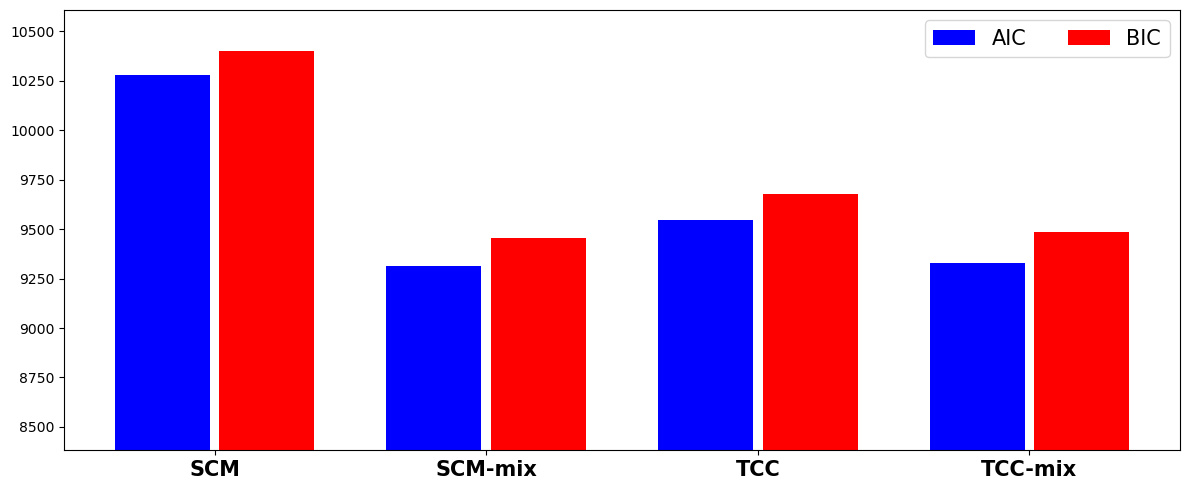

In [34]:
# AIC & BIC model comparison visualization
fig, ax = plt.subplots(figsize = (12,5))

x = np.arange(len(comparison_metrics_df['model']))
width = 0.35

ax.bar(x - 0.55*width, comparison_metrics_df['AIC'], width,
       color='blue', label='AIC')

ax.bar(x + 0.55*width, comparison_metrics_df['BIC'], width,
       color='red', label='BIC')

ax.set_xticks(x)
model_names_plot = ['SCM', 'SCM-mix', 'TCC', 'TCC-mix']
ax.set_xticklabels(model_names_plot,fontsize = 15, fontweight='bold')

miny = comparison_metrics_df[['AIC','BIC']].min().min()*.9
maxy = comparison_metrics_df[['AIC','BIC']].max().max()*1.02
ax.set_ylim([miny, maxy])

ax.legend(fontsize = 15, loc = 'upper right', ncol = 2)
plt.tight_layout()
plt.show()

## Correlations

In [35]:
def compute_correlations(pred_probs, observed_counts, 
                         SET_SIZES, POSITIONS, SUBJECTS):
    n_subj  = len(SUBJECTS)
    n_cond  = N_SS * N_POS

    # observed proportions: (C, 16, 16)
    obs_counts = observed_counts.reshape(n_subj, n_cond, 16, 16)
    obs_props  = obs_counts / (obs_counts.sum(axis=-1, keepdims=True) + 1e-12)
    obs_mean   = obs_props.mean(axis=0)   # (n_cond, 16, 16) - mean across subjects

    # predicted: average across subjects
    pred_mean = pred_probs.reshape(n_subj, n_cond, 16, 16).mean(axis=0)  # (n_cond, 16, 16)

    # Print the results in a nice table
    print(f"{'Condition':<20} {'r':<10} {'p-value':<15}")
    print("-" * 45)

    results = []
    for i, ss in enumerate(SET_SIZES):
        for j, pos in enumerate(POSITIONS):
            cond_idx = i * N_POS + j
            pred = pred_mean[cond_idx].flatten()
            obs  = obs_mean[cond_idx].flatten()
            r, p = pearsonr(pred, obs)
            results.append({'set_size': ss, 'position': pos, 'r': r, 'p': p})
            print(f"SS={ss}, Pos={pos:<8} r={r:.3f}    p={p:.3f}")

    return pd.DataFrame(results)

In [36]:
for name, (pred_probs, pred_counts) in predictions_dict.items():
    print(f"{'='*30} Correlations for {name} {'='*30}")
    compute_correlations(pred_probs, data_matrix, SET_SIZES, POSITIONS, SUBJECTS)
    print("\n")

============================== Correlations for SCM ==============================
Condition            r          p-value        
---------------------------------------------
SS=2, Pos=3        r=0.935    p=0.000
SS=2, Pos=7        r=0.964    p=0.000
SS=2, Pos=11       r=0.960    p=0.000
SS=2, Pos=15       r=0.947    p=0.000
SS=5, Pos=3        r=0.860    p=0.000
SS=5, Pos=7        r=0.883    p=0.000
SS=5, Pos=11       r=0.805    p=0.000
SS=5, Pos=15       r=0.816    p=0.000
SS=8, Pos=3        r=0.897    p=0.000
SS=8, Pos=7        r=0.900    p=0.000
SS=8, Pos=11       r=0.880    p=0.000
SS=8, Pos=15       r=0.871    p=0.000


============================== Correlations for SCM-mix ==============================
Condition            r          p-value        
---------------------------------------------
SS=2, Pos=3        r=0.968    p=0.000
SS=2, Pos=7        r=0.978    p=0.000
SS=2, Pos=11       r=0.986    p=0.000
SS=2, Pos=15       r=0.975    p=0.000
SS=5, Pos=3        r=0.942    p=

## Visualization

In [37]:
# Match colors on the plot to those in the paper (the actual presented colors)
L, a_center, b_center, radius = 50, 10, 10, 40
angles = np.linspace(0, -360, 16, endpoint=False)
angles_rad = np.deg2rad(angles)

item_colors = []
for angle in angles_rad:
    a = a_center + radius * np.cos(angle)
    b = b_center + radius * np.sin(angle)
    lab = LabColor(L, a, b)
    rgb = convert_color(lab, sRGBColor)
    r  = np.clip(rgb.clamped_rgb_r, 0, 1)
    g  = np.clip(rgb.clamped_rgb_g, 0, 1)
    b_ = np.clip(rgb.clamped_rgb_b, 0, 1)
    item_colors.append((r, g, b_))

In [38]:
def plot_predicted_vs_observed(pred_probs, observed_counts, SET_SIZES, POSITIONS, SUBJECTS,
                                model_name='Model',
                                error_type='ci',
                                markersize=6,
                                legend_fontsize=10,
                                legend_title_fontsize=15,
                                legend_markersize=15):

    n_subj  = len(SUBJECTS)
    n_cond  = N_SS * N_POS

    # observed proportions
    obs_counts = observed_counts.reshape(n_subj, n_cond, 16, 16)
    obs_props  = obs_counts / (obs_counts.sum(axis=-1, keepdims=True) + 1e-12)  # (n_subj, n_cond, 16, 16)

    # predicted: reshape to (n_subj, n_cond, 16, 16)
    pred_reshaped = pred_probs.reshape(n_subj, n_cond, 16, 16)

    colors = item_colors

    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                   markerfacecolor=colors[row],
                                   markersize=legend_markersize,
                                   label=f'Item {row+1}')
                       for row in range(16)]

    fig = plt.figure(figsize=(14, 11))

    legend_ax = fig.add_axes([0, 0.88, 1, 0.06])
    legend_ax.axis('off')
    legend_ax.legend(handles=legend_elements, loc='center', ncol=8,
                     fontsize=legend_fontsize,
                     title='Studied item',
                     title_fontsize=legend_title_fontsize,
                     frameon=True,
                     labelspacing=0.85)

    fig.suptitle(f'{model_name}: Predicted vs Observed\n(all subjects)',
                 fontsize=20, fontweight='bold', y=1.01)

    gs = fig.add_gridspec(N_SS, N_POS, top=0.84, bottom=0.08,
                          left=0.08, right=0.98,
                          hspace=0.15, wspace=0.2)
    axes = gs.subplots(sharex=True, sharey=True)

    for i, ss in enumerate(SET_SIZES):
        for j, pos in enumerate(POSITIONS):
            ax       = axes[i, j]
            cond_idx = i * N_POS + j

            pred_cond = pred_reshaped[:, cond_idx, :, :]   # (n_subj, 16, 16)
            obs_cond  = obs_props[:, cond_idx, :, :]        # (n_subj, 16, 16)

            for row in range(16):
                pred_mean = pred_cond[:, row, :].mean(axis=0)   # (16,)
                pred_std  = pred_cond[:, row, :].std(axis=0)

                obs_mean  = obs_cond[:, row, :].mean(axis=0)    # (16,)
                obs_std   = obs_cond[:, row, :].std(axis=0)

                if error_type == 'ci':
                    t_crit = stats.t.ppf(0.975, df=n_subj - 1)
                    xerr   = t_crit * pred_std / np.sqrt(n_subj)
                    yerr   = t_crit * obs_std  / np.sqrt(n_subj)
                else:
                    xerr = pred_std / np.sqrt(n_subj)
                    yerr = obs_std  / np.sqrt(n_subj)

                ax.errorbar(pred_mean, obs_mean, yerr=yerr, xerr=xerr,
                            fmt='o', markersize=markersize, alpha=0.7,
                            elinewidth=0.8, capsize=2,
                            color=colors[row])

            ax.plot([0, 1], [0, 1], 'r--', linewidth=1)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_title(f'SS={ss}, Pos={pos}', fontsize=10)

    if error_type == 'ci':
        y_label = 'Observed Probability\n(mean ± 95% CI)'
        x_label = 'Predicted Probability\n(mean ± 95% CI)'
    else:
        y_label = 'Observed Probability\n(mean ± SEM)'
        x_label = 'Predicted Probability\n(mean ± SEM)'

    fig.text(0.5,  0.02, x_label, ha='center',
             fontsize=15, fontweight='bold')
    fig.text(0.01, 0.45, y_label, va='center', rotation='vertical',
             multialignment='center', fontsize=15, fontweight='bold')
    plt.show()


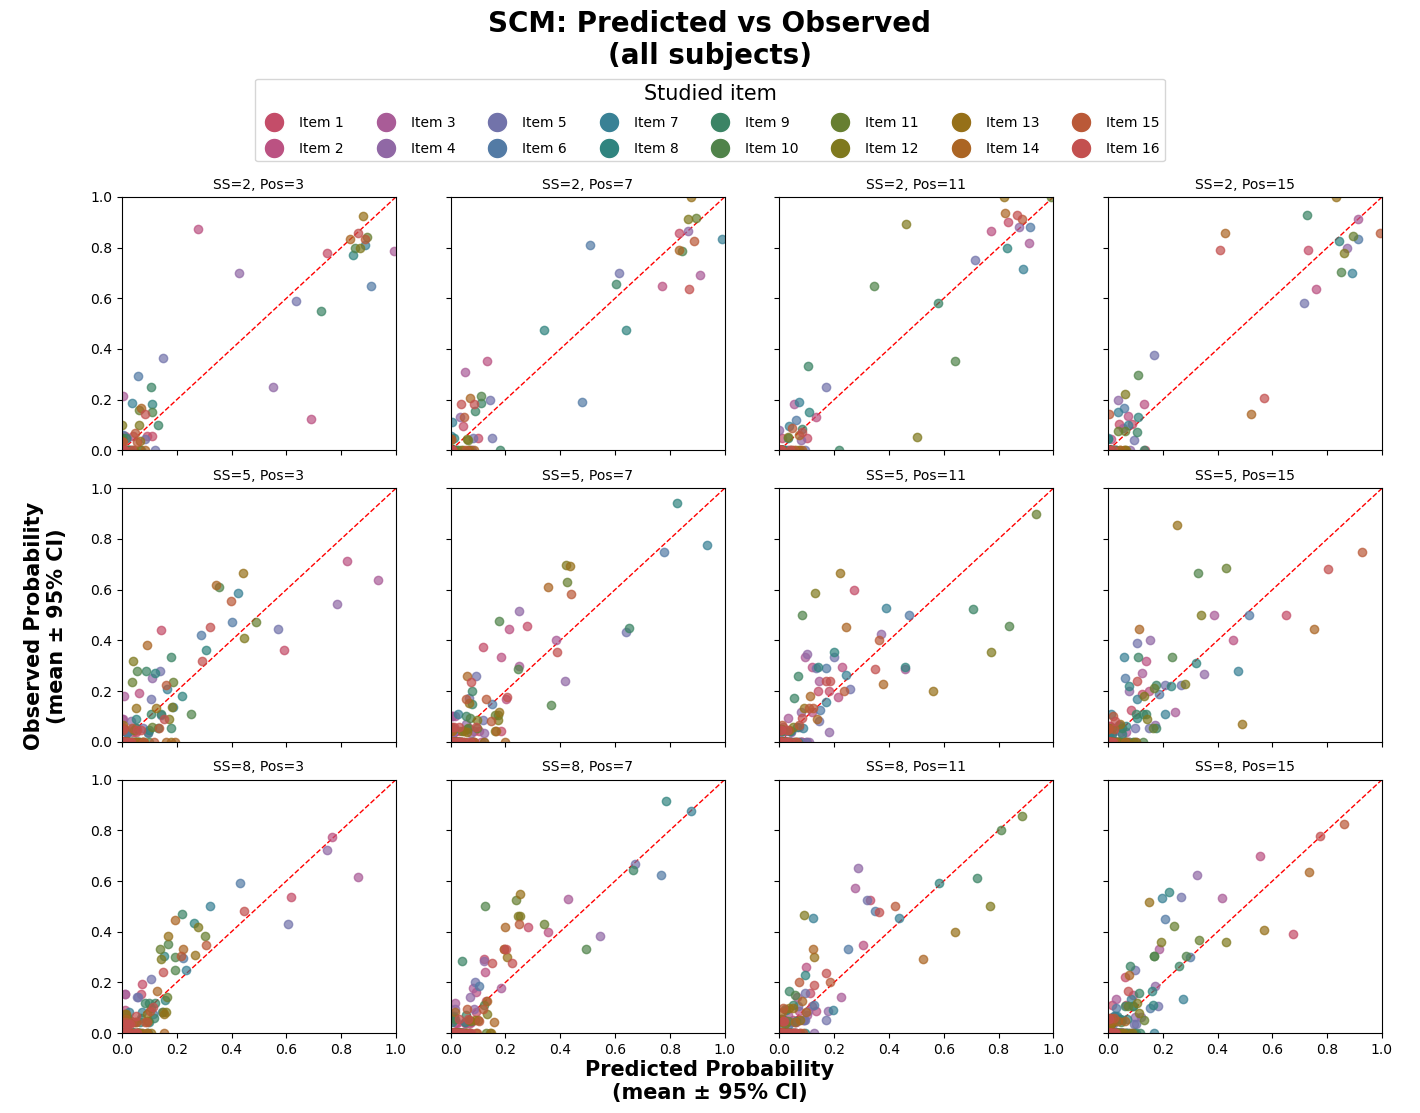

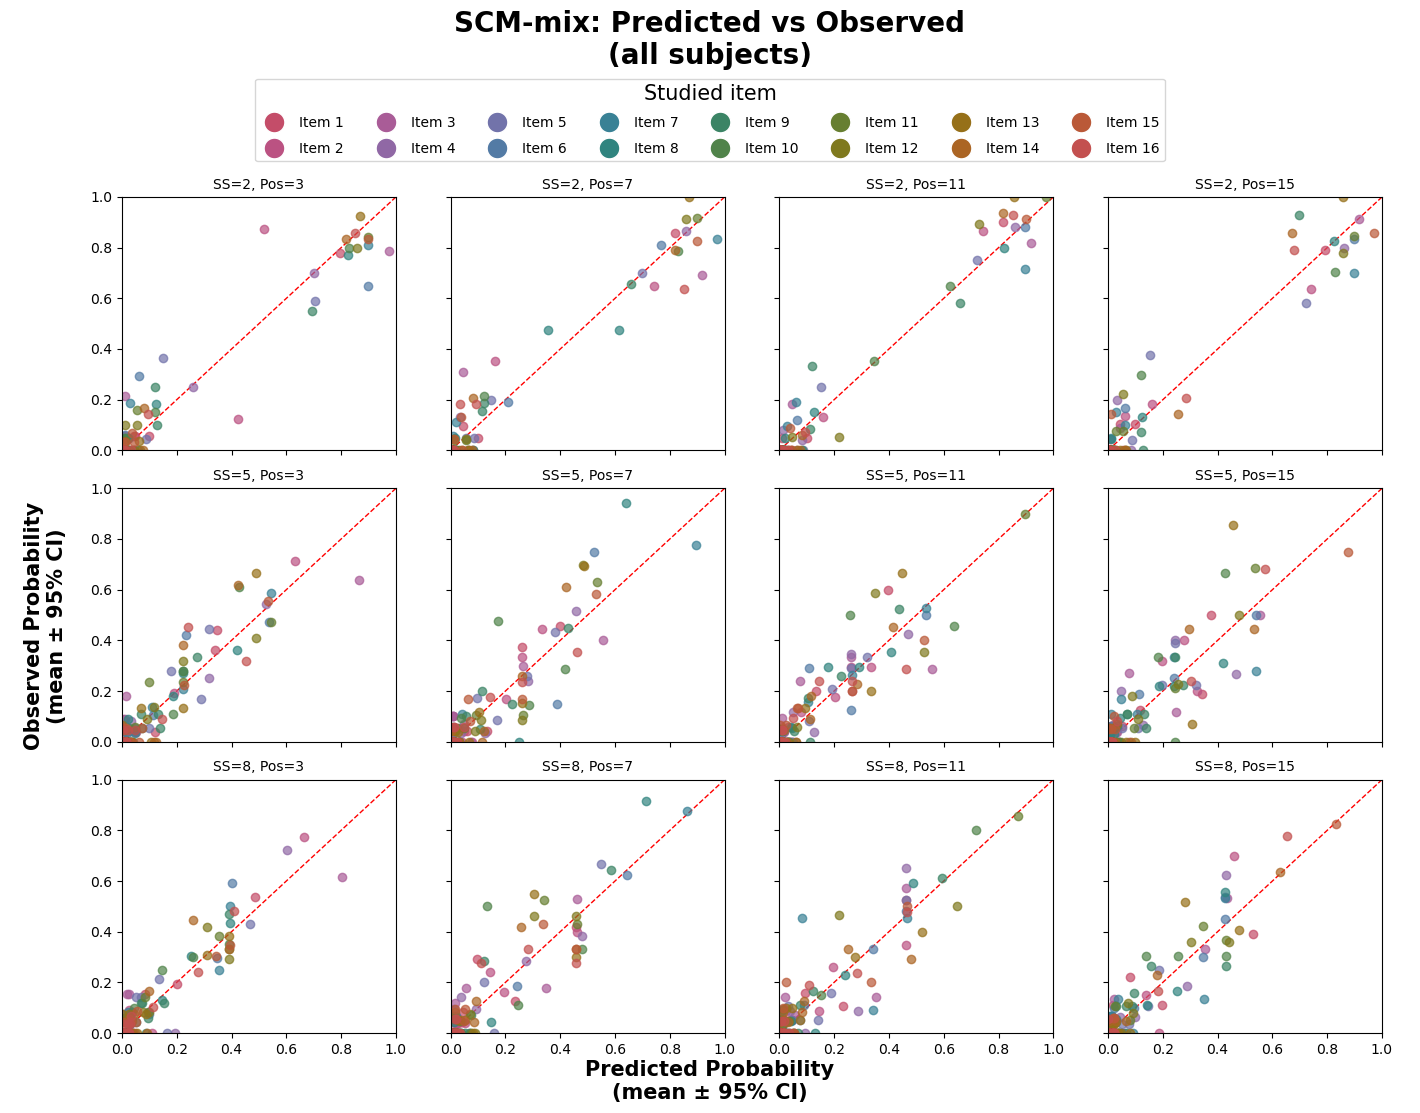

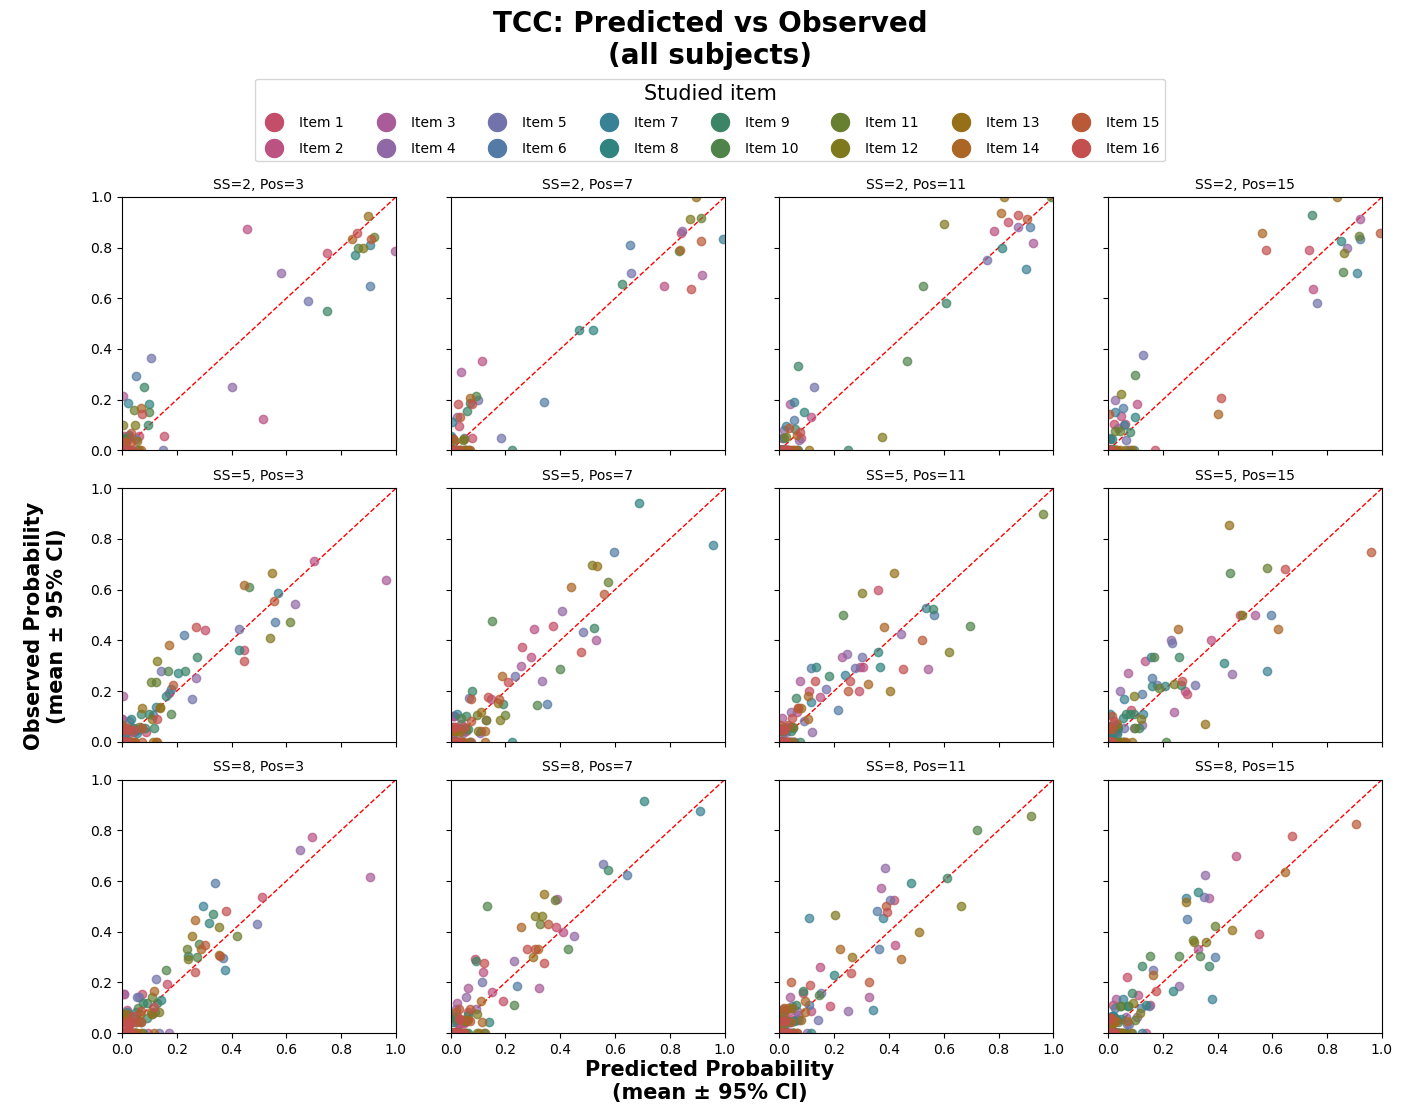

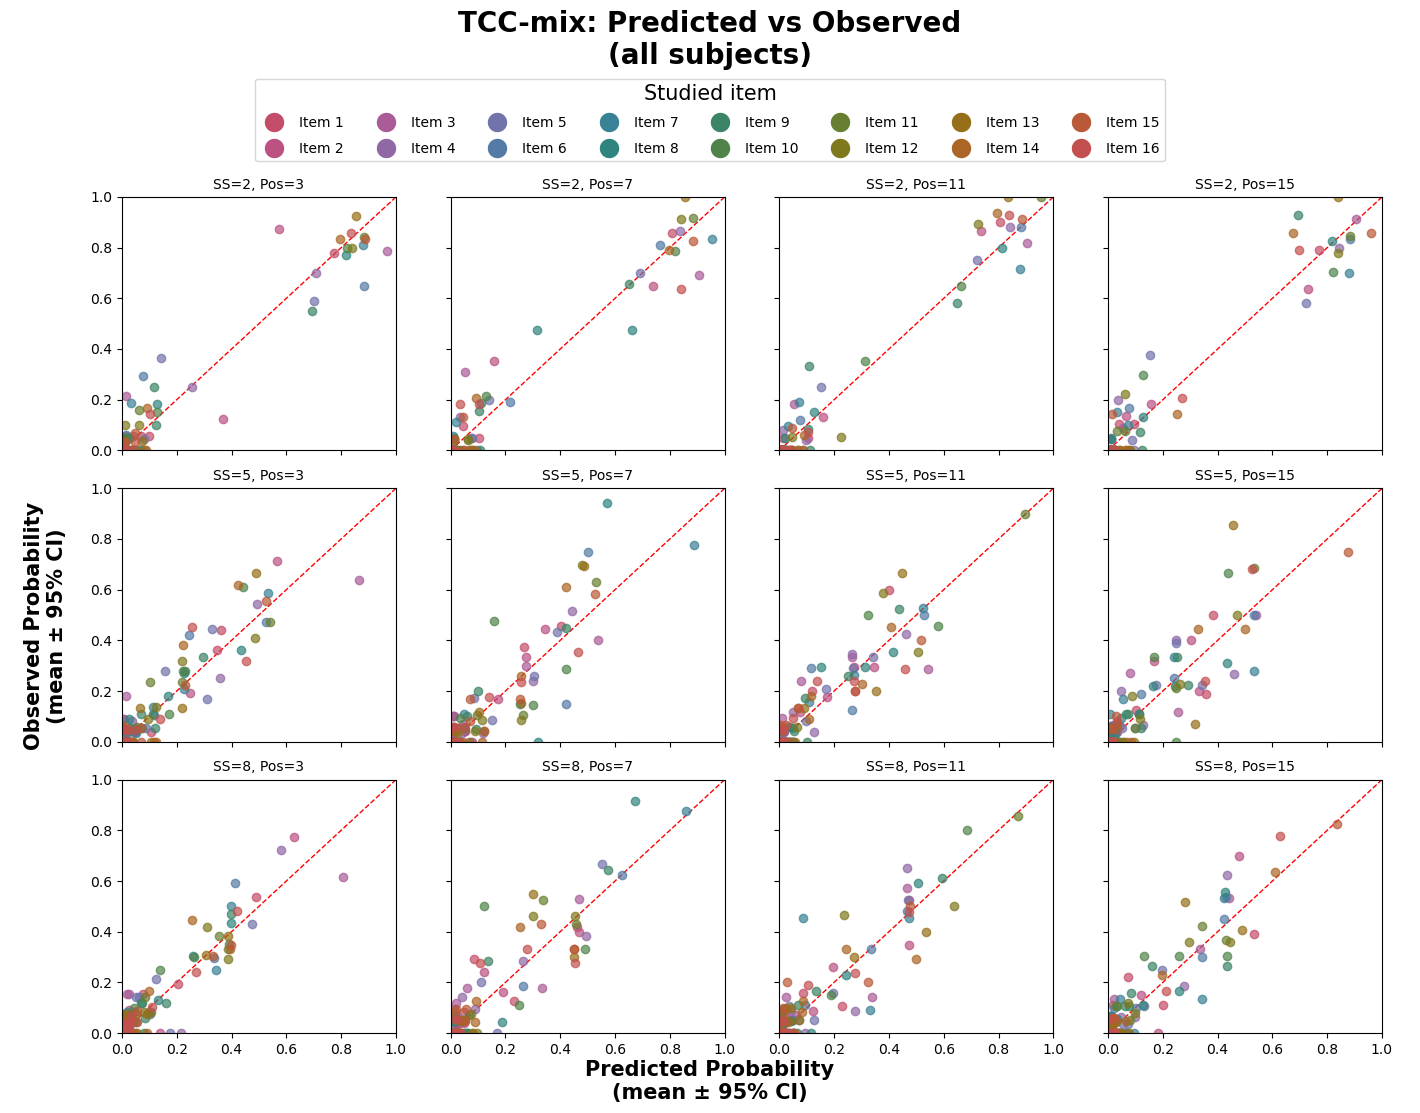

In [39]:
for name, (pred_probs, pred_counts) in predictions_dict.items():
    plot_predicted_vs_observed(pred_probs, data_matrix, SET_SIZES, POSITIONS, SUBJECTS, model_name=name)

## Aggregated accross conditions

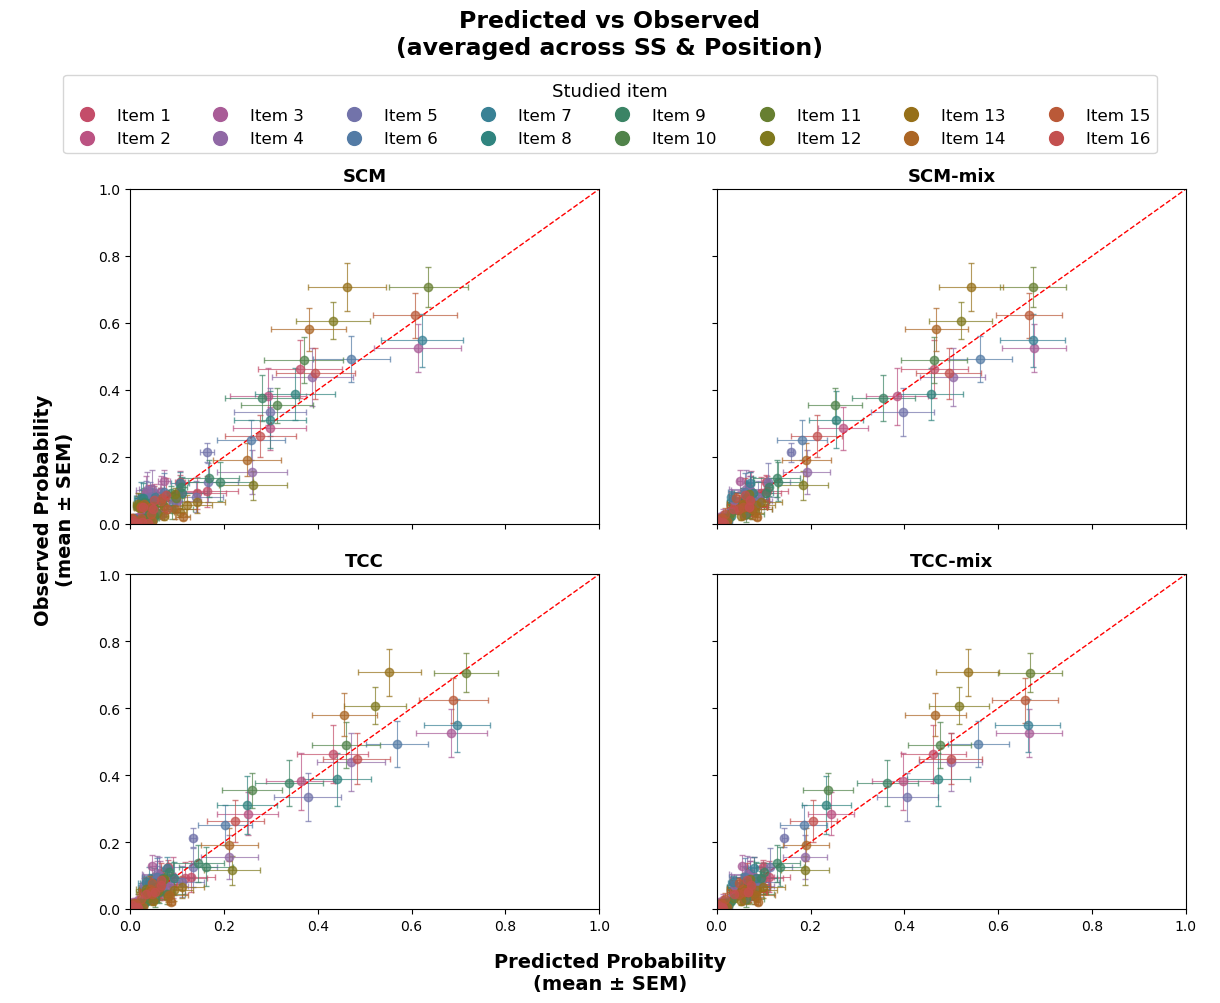

In [40]:
def plot_predicted_vs_observed_comparison(predictions_dict,
                                           observed_counts,
                                           SUBJECTS, SET_SIZES, POSITIONS,
                                           error_type='sem',
                                           markersize=6,
                                           legend_fontsize=12,
                                           legend_title_fontsize=13,
                                           legend_markersize=12):
    colors  = item_colors
    n_subj  = len(SUBJECTS)
    n_cond  = N_SS * N_POS

    # observed proportions: (n_subj, n_cond, 16, 16)
    obs_counts = observed_counts.reshape(n_subj, n_cond, 16, 16)
    obs_props  = obs_counts / (obs_counts.sum(axis=-1, keepdims=True) + 1e-12)

    legend_elements = [plt.Line2D([0], [0], marker='o', color='w',
                                   markerfacecolor=colors[row],
                                   markersize=legend_markersize,
                                   label=f'Item {row+1}')
                       for row in range(16)]

    layout = [
        ['SCM',  'SCM-mix'],
        ['TCC',  'TCC-mix'],
    ]
    nrows, ncols = 2, 2

    fig = plt.figure(figsize=(12, 10))

    legend_ax = fig.add_axes([0, 0.86, 1, 0.07])
    legend_ax.axis('off')
    legend_ax.legend(handles=legend_elements, loc='center', ncol=8,
                     fontsize=legend_fontsize,
                     title='Studied item',
                     title_fontsize=legend_title_fontsize,
                     frameon=True,
                     labelspacing=0.5)

    fig.suptitle('Predicted vs Observed\n(averaged across SS & Position)',
                 fontsize=legend_title_fontsize+4, fontweight='bold', y=1.0)

    gs = fig.add_gridspec(nrows, ncols, top=0.82, bottom=0.1,
                          left=0.1, right=0.98,
                          hspace=0.15, wspace=0.25)
    axes = gs.subplots(sharex=True, sharey=True)

    for row_idx, row_layout in enumerate(layout):
        for col_idx, model_name in enumerate(row_layout):
            ax = axes[row_idx, col_idx]

            if model_name is None or model_name not in predictions_dict:
                ax.set_visible(False)
                continue

            # pred_probs: (n_subj*n_cond, 16, 16) → (n_subj, n_cond, 16, 16)
            pred_probs   = predictions_dict[model_name][0]
            pred_reshaped = pred_probs.reshape(n_subj, n_cond, 16, 16)

            for item in range(16):
                pred_item = pred_reshaped[:, :, item, :]   # (n_subj, n_cond, 16)
                obs_item  = obs_props[:, :, item, :]        # (n_subj, n_cond, 16)

                # average across subjects and conditions
                pred_mean = pred_item.mean(axis=(0, 1))     # (16,)
                pred_std  = pred_item.std(axis=(0, 1))
                obs_mean  = obs_item.mean(axis=(0, 1))      # (16,)
                obs_std   = obs_item.std(axis=(0, 1))

                n = n_subj * n_cond
                if error_type == 'ci':
                    t_crit = stats.t.ppf(0.975, df=n - 1)
                    xerr   = t_crit * pred_std / np.sqrt(n)
                    yerr   = t_crit * obs_std  / np.sqrt(n)
                else:
                    xerr = pred_std / np.sqrt(n)
                    yerr = obs_std  / np.sqrt(n)

                ax.errorbar(pred_mean, obs_mean,
                            yerr=yerr, xerr=xerr,
                            fmt='o', markersize=markersize, alpha=0.7,
                            elinewidth=0.8, capsize=2,
                            color=colors[item])

            ax.plot([0, 1], [0, 1], 'r--', linewidth=1)
            ax.set_title(model_name, fontsize=legend_title_fontsize, fontweight='bold')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)

    if error_type == 'ci':
        y_label = 'Observed Probability\n(mean ± 95% CI)'
        x_label = 'Predicted Probability\n(mean ± 95% CI)'
    else:
        y_label = 'Observed Probability\n(mean ± SEM)'
        x_label = 'Predicted Probability\n(mean ± SEM)'

    fig.text(0.5,  0.02, x_label, ha='center',
             fontsize=legend_title_fontsize+1, fontweight='bold',
             multialignment='center')
    fig.text(0.02, 0.5,  y_label, va='center', rotation='vertical',
             fontsize=legend_title_fontsize+1, fontweight='bold',
             multialignment='center')

    plt.show()


# ==================== Plot ====================
plot_predicted_vs_observed_comparison(predictions_dict, data_matrix,
                                      SUBJECTS, SET_SIZES, POSITIONS,
                                      error_type='sem')

## Subj 4

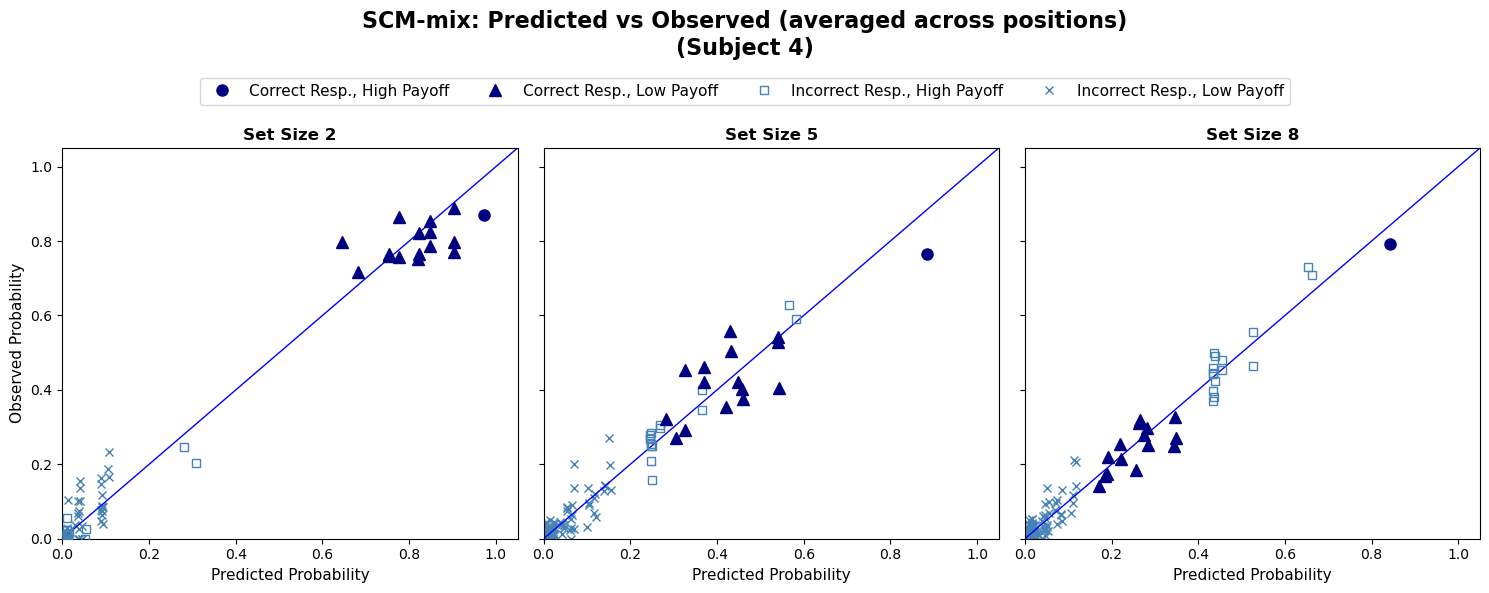

In [41]:
def plot_pred_vs_obs_subject_avgpos(pred_probs, observed_counts,
                                    SET_SIZES, POSITIONS, SUBJECTS,
                                    subject_id=4,
                                    model_name='Model'):

    n_subj  = len(SUBJECTS)
    n_cond  = N_SS * N_POS

    # reshape predictions and observations to (n_subj, n_cond, 16, 16)
    pred_reshaped = pred_probs.reshape(n_subj, n_cond, 16, 16)
    obs_counts_r  = observed_counts.reshape(n_subj, n_cond, 16, 16)

    # get subject index
    subj_list = list(SUBJECTS)
    subj_idx  = subj_list.index(subject_id)

    pred_subj = pred_reshaped[subj_idx]   # (n_cond, 16, 16)
    obs_subj  = obs_counts_r[subj_idx]    # (n_cond, 16, 16)

    fig, axes = plt.subplots(1, N_SS, figsize=(15, 6), sharey=True)
    fig.suptitle(f'{model_name}: Predicted vs Observed (averaged across positions)\n(Subject {subject_id})',
                 fontsize=16, fontweight='bold')

    styles = {
        'correct_high':   dict(marker='o', color='navy',      markersize=8, label='Correct Resp., High Payoff',   linestyle='None', zorder=5),
        'correct_low':    dict(marker='^', color='navy',      markersize=8, label='Correct Resp., Low Payoff',    linestyle='None', zorder=4),
        'incorrect_high': dict(marker='s', color='steelblue', markersize=6, label='Incorrect Resp., High Payoff', linestyle='None', markerfacecolor='none', zorder=3),
        'incorrect_low':  dict(marker='x', color='steelblue', markersize=6, label='Incorrect Resp., Low Payoff',  linestyle='None', zorder=2),
    }

    for i, ss in enumerate(SET_SIZES):
        ax = axes[i]

        pred_relabeled = np.zeros((N_POS, 16, 16))
        obs_relabeled  = np.zeros((N_POS, 16, 16))

        for j, pos in enumerate(POSITIONS):
            cond_idx = i * N_POS + j
            p = pos - 1

            pred_mat = pred_subj[cond_idx]                                    # (16, 16)
            pred_relabeled[j] = np.roll(np.roll(pred_mat, -p, axis=0), -p, axis=1)

            obs_mat = obs_subj[cond_idx].astype(float)                        # (16, 16)
            obs_mat = obs_mat / (obs_mat.sum(axis=1, keepdims=True) + 1e-12)
            obs_relabeled[j]  = np.roll(np.roll(obs_mat,  -p, axis=0), -p, axis=1)

        pred_avg = pred_relabeled.mean(axis=0)                                # (16, 16)
        obs_avg  = obs_relabeled.mean(axis=0)                                 # (16, 16)

        cat_pred = {k: [] for k in styles}
        cat_obs  = {k: [] for k in styles}

        for row in range(16):
            for col in range(16):
                correct = (row == col)
                high    = (col == 0)

                if correct and high:
                    cat = 'correct_high'
                elif correct and not high:
                    cat = 'correct_low'
                elif not correct and high:
                    cat = 'incorrect_high'
                else:
                    cat = 'incorrect_low'

                cat_pred[cat].append(pred_avg[row, col])
                cat_obs[cat].append(obs_avg[row, col])

        for cat, style in styles.items():
            if cat_pred[cat]:
                ax.plot(cat_pred[cat], cat_obs[cat], **style)

        lim = 1.05
        ax.plot([0, lim], [0, lim], 'b-', linewidth=1)
        ax.set_xlim(0, lim)
        ax.set_ylim(0, lim)
        ax.set_title(f'Set Size {ss}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted Probability', fontsize=11)
        if i == 0:
            ax.set_ylabel('Observed Probability', fontsize=11)

    handles = [plt.Line2D([0], [0], **{k: v for k, v in s.items() if k != 'zorder'})
               for s in styles.values()]
    labels  = [s['label'] for s in styles.values()]
    fig.legend(handles, labels, fontsize=11, loc='upper center',
               bbox_to_anchor=(0.5, 0.88), ncol=4, frameon=True)

    plt.tight_layout()
    plt.subplots_adjust(top=0.75)
    plt.show()


# Plot for Subject 4 (Fig 8 in the paper)
plot_pred_vs_obs_subject_avgpos(SCM_mix_predictions[0], data_matrix,
                                SET_SIZES, POSITIONS, SUBJECTS,
                                subject_id=4, model_name='SCM-mix')

## Slides

In [42]:
# This is for visualization in Google Slides 
# (to match the colors of the items in the experiment using HEX or RGB values)

def to_hex(r, g, b):
    return '#{:02x}{:02x}{:02x}'.format(int(r*255), int(g*255), int(b*255))

def to_rgb255(r, g, b):
    return (int(r*255), int(g*255), int(b*255))

for i, (r, g, b) in enumerate(item_colors):
    print(f"Color {i}: hex={to_hex(r,g,b)}, rgb={to_rgb255(r,g,b)}")

Color 0: hex=#c34d68, rgb=(195, 77, 104)
Color 1: hex=#ba5181, rgb=(186, 81, 129)
Color 2: hex=#a95b97, rgb=(169, 91, 151)
Color 3: hex=#9067a5, rgb=(144, 103, 165)
Color 4: hex=#7272aa, rgb=(114, 114, 170)
Color 5: hex=#537ba4, rgb=(83, 123, 164)
Color 6: hex=#398095, rgb=(57, 128, 149)
Color 7: hex=#30837e, rgb=(48, 131, 126)
Color 8: hex=#3b8464, rgb=(59, 132, 100)
Color 9: hex=#4f8249, rgb=(79, 130, 73)
Color 10: hex=#677e30, rgb=(103, 126, 48)
Color 11: hex=#7f781e, rgb=(127, 120, 30)
Color 12: hex=#966f18, rgb=(150, 111, 24)
Color 13: hex=#aa6423, rgb=(170, 100, 35)
Color 14: hex=#ba5937, rgb=(186, 89, 55)
Color 15: hex=#c3504f, rgb=(195, 80, 79)


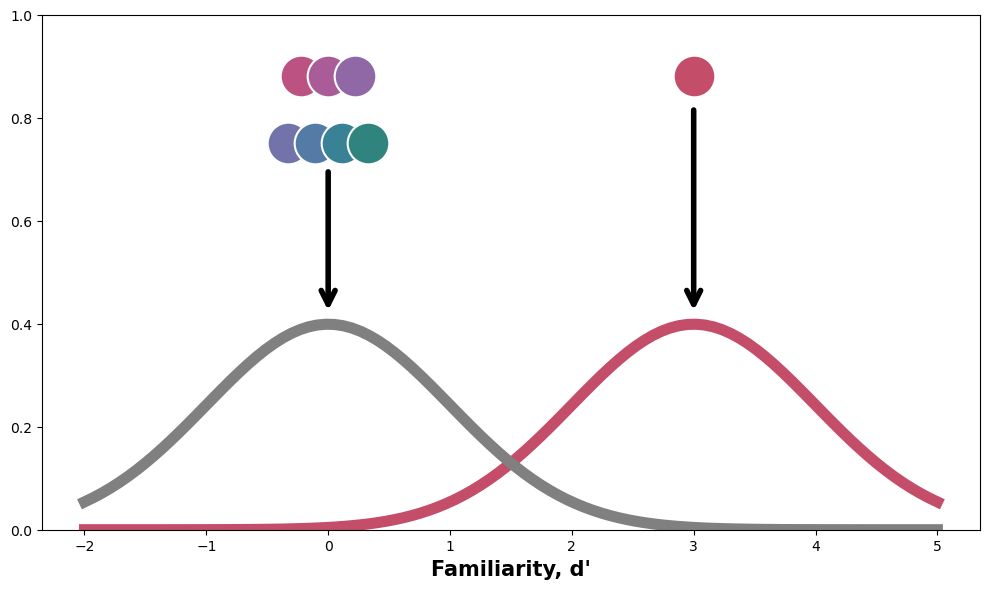

In [ ]:
Xs = np.linspace(-2, 5, 100)
item1_d = 3
pdfs = stats.norm.pdf(Xs, loc=item1_d, scale=1)
pdf_noise = stats.norm.pdf(Xs, loc=0, scale=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(Xs, pdfs, color=item_colors[0], linewidth=8)
ax.plot(Xs, pdf_noise, color='grey', linewidth=8)

ax.set_xlabel("Familiarity, d'", fontsize=15, fontweight="bold")
ax.set_ylim((0, 1))

# --- Circle layout ---
circle_size = 900
circle_y_top = 0.88   # top row y
circle_y_bot = 0.75   # bottom row y
x_spacing = 0.22      # horizontal spacing between circles

# Cluster of 7 circles above noise distribution (centered on x=0)
# Arranged as: 3 on top row, 4 on bottom row
top_row_n = 3
bot_row_n = 4

top_xs = np.linspace(-(top_row_n - 1) / 2 * x_spacing,
                      (top_row_n - 1) / 2 * x_spacing, top_row_n)
bot_xs = np.linspace(-(bot_row_n - 1) / 2 * x_spacing,
                      (bot_row_n - 1) / 2 * x_spacing, bot_row_n)

cluster_colors = item_colors[1:8]  # 7 colors for the 7 distractor circles

for i, cx in enumerate(top_xs):
    ax.scatter(cx, circle_y_top, s=circle_size, color=cluster_colors[i],
               zorder=5, edgecolors='white', linewidths=1.5)

for i, cx in enumerate(bot_xs):
    ax.scatter(cx, circle_y_bot, s=circle_size, color=cluster_colors[top_row_n + i],
               zorder=5, edgecolors='white', linewidths=1.5)

# Arrow from cluster center down to noise curve peak (x=0)
cluster_arrow_y_start = circle_y_bot - 0.05
ax.annotate('', xy=(0, 0.42), xytext=(0, cluster_arrow_y_start),
            arrowprops=dict(arrowstyle='->', color='black', lw=4,
                            mutation_scale=25))

# Single target circle above signal distribution (x=3)
ax.scatter(3, circle_y_top, s=circle_size, color=item_colors[0],
           zorder=5, edgecolors='white', linewidths=1.5)

# Arrow from single circle down to signal curve peak (x=3)
ax.annotate('', xy=(3, 0.42), xytext=(3, circle_y_top - 0.06),
            arrowprops=dict(arrowstyle='->', color='black', lw=4,
                            mutation_scale=25))

plt.tight_layout()
plt.show()

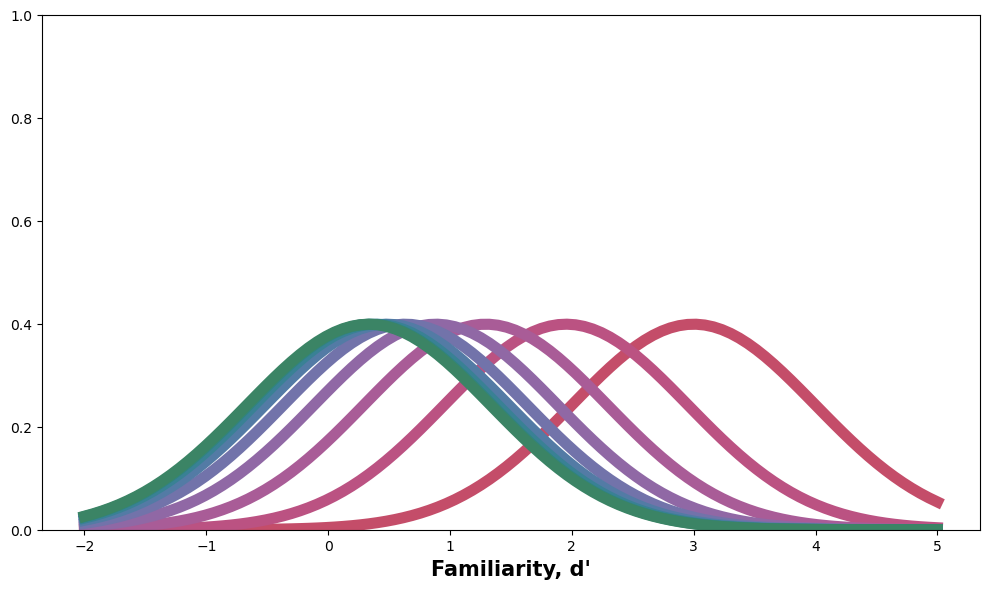

In [44]:
n_obj = 9
Xs = np.linspace(-2,5,100)
dist = distances[0][:n_obj]
item1_d = 3
c = 1.1
sim = np.exp(-c * dist)
all_d = item1_d * sim

fig, ax = plt.subplots(figsize=(10,6))
pdfs = stats.norm.pdf(Xs[None,:], loc=all_d[:,None], scale=1)
for i in range(pdfs.shape[0]):
    plt.plot(Xs, pdfs[i], color = item_colors[i], linewidth=8)

ax.set_xlabel("Familiarity, d'", fontsize=15, fontweight="bold")
ax.set_ylim((0,1))
plt.tight_layout()
plt.show()

In [45]:
# Visualization of how integral is calculated for d'
def integral_vis(n_obj = 9,
                 Xs = np.linspace(-2,5,100),
                 item1_d = 3,
                 c = 1.1,
                 pdf_idx = 0,
                 x_integral = 3.5):

    dist = distances[0][:n_obj]
    sim = np.exp(-c * dist)
    all_d = item1_d * sim

    fig, ax = plt.subplots(figsize=(10,6))
    pdfs = stats.norm.pdf(Xs, loc=all_d[pdf_idx], scale=1) # target
    cdfs = stats.norm.cdf(Xs[None, :], loc = all_d[:, None], scale = 1)

    for i in range(n_obj):
        if i == pdf_idx:
            plt.plot(Xs, pdfs, color = item_colors[i], linewidth=8)
        else:
            plt.plot(Xs, cdfs[i], color = item_colors[i], linewidth=8)

    plt.axvline(x=x_integral, linestyle='--', linewidth=2, color='black')

    xticks = list(ax.get_xticks()) + [x_integral]
    ax.set_xticks(xticks)

    labels = []
    fw = []
    for t in xticks:
        if np.isclose(t, x_integral):
            labels.append('x')
            fw.append('bold')
        else:
            labels.append(f"{t:g}")
            fw.append('normal')

    ax.set_xticklabels(labels)

    for label, t in zip(ax.get_xticklabels(), xticks):
        if np.isclose(t, x_integral):
            label.set_fontweight('bold')
            label.set_fontsize(25)   # bigger for the special tick

    ax.set_xlabel("Familiarity, d'", fontsize=15, fontweight="bold")
    ax.set_ylim((0,1))
    plt.tight_layout()
    plt.show()

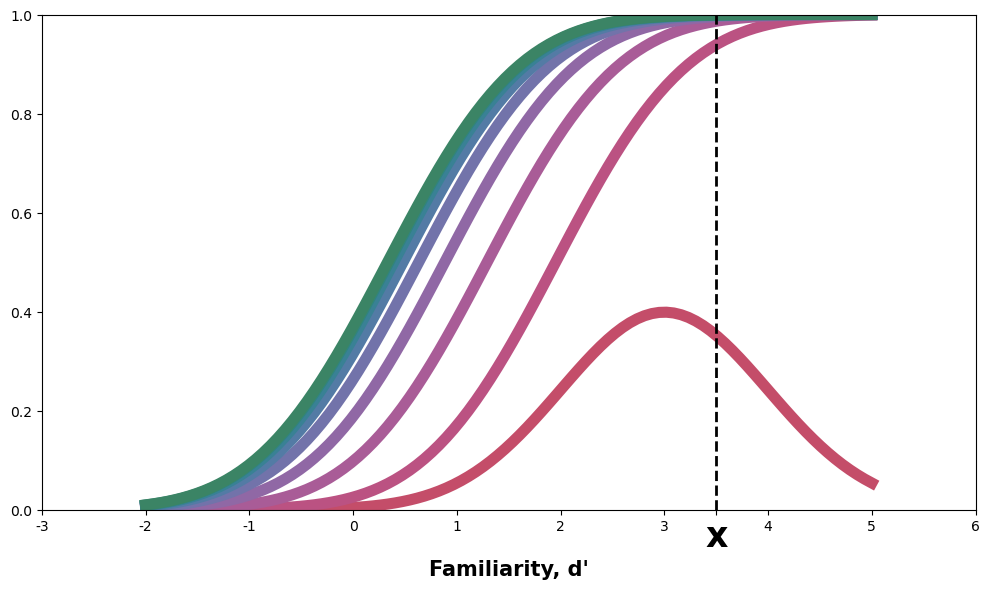

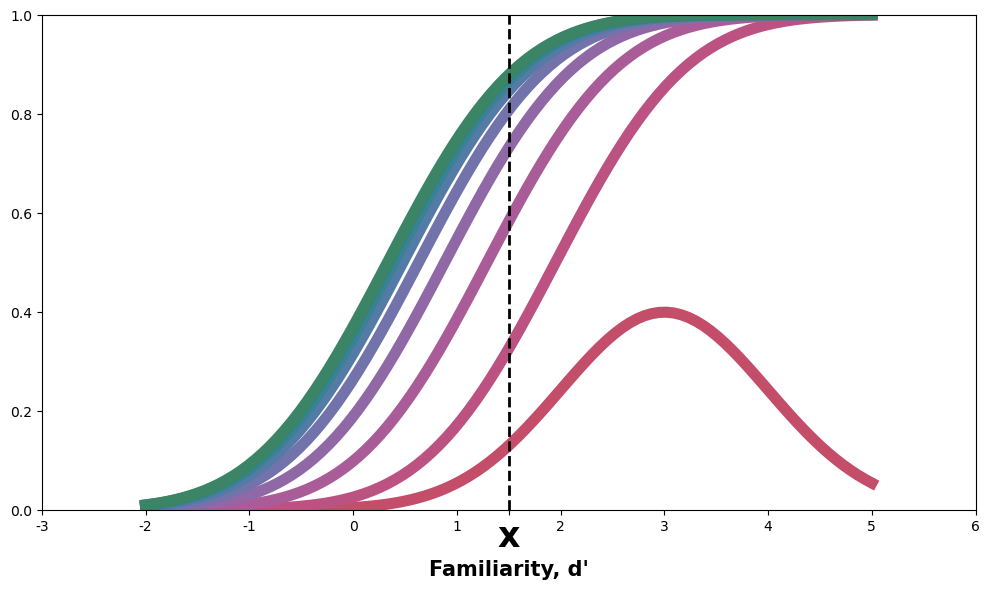

In [46]:
# Target
integral_vis(pdf_idx = 0, x_integral = 3.5)
integral_vis(pdf_idx = 0, x_integral = 1.5)

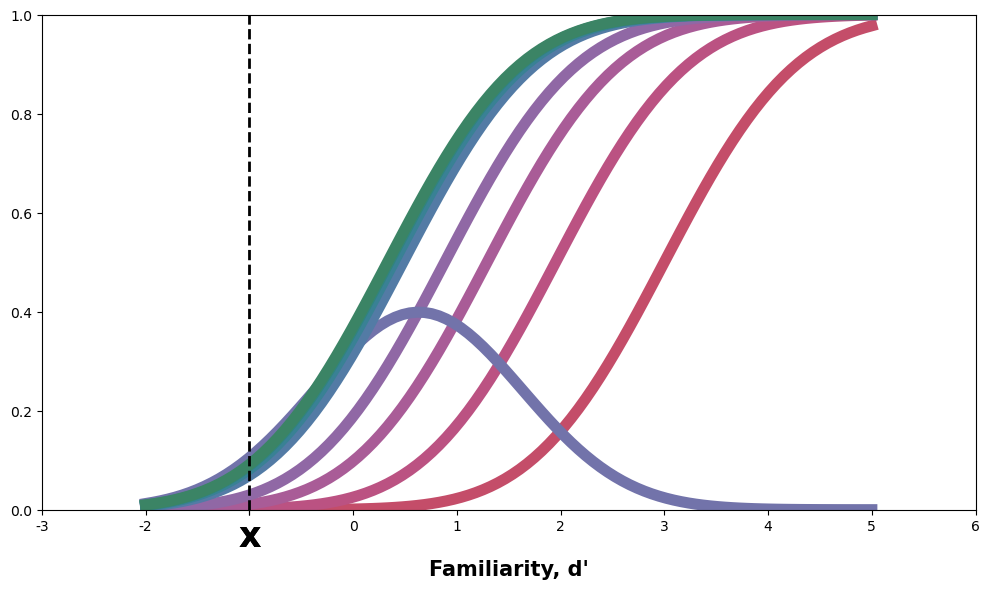

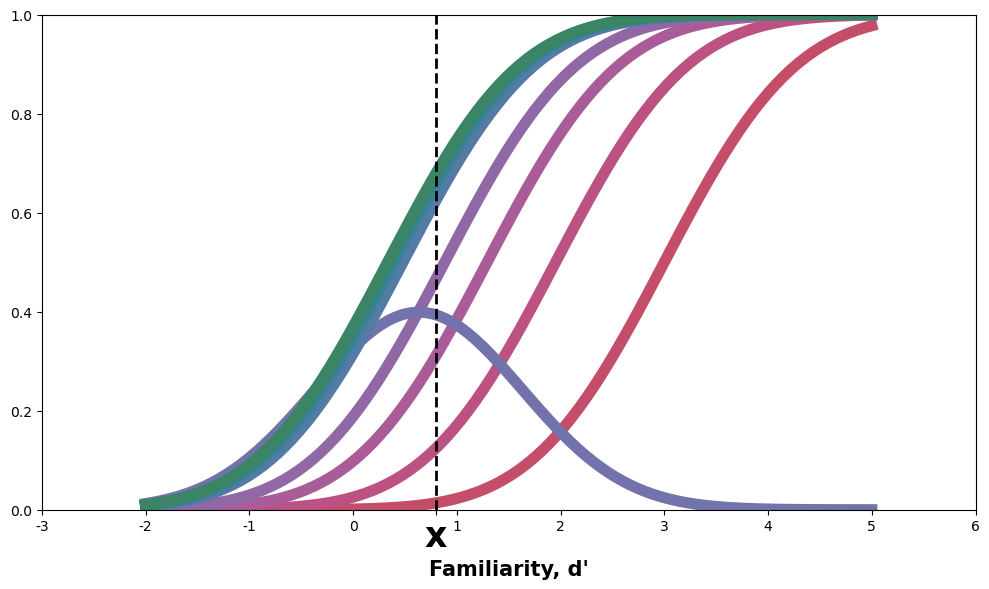

In [47]:
# Foil
integral_vis(pdf_idx = 4, x_integral = -1.0)
integral_vis(pdf_idx = 4, x_integral = 0.8)

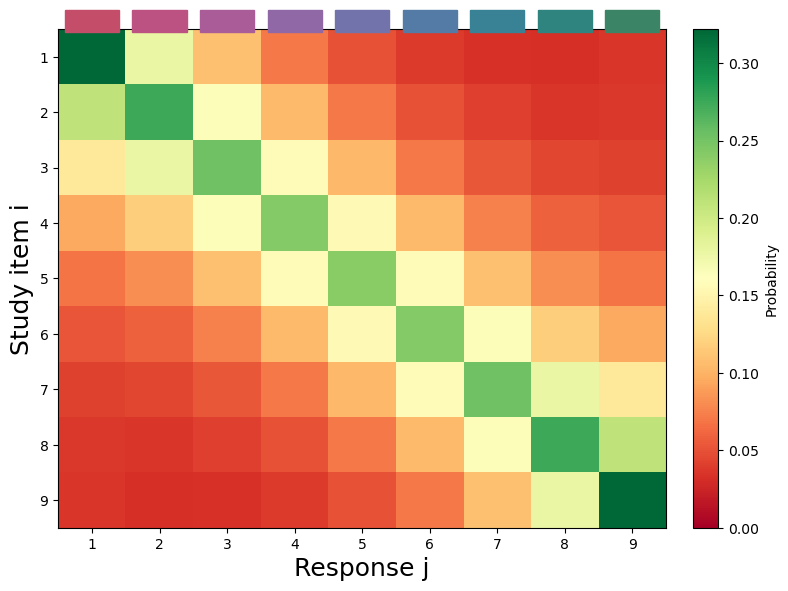

In [287]:
# # 8 items on a circle
# n = 9
# dists = distances[:9,:9]

# # Similarity and probabilities
# c_val = 1.1
# sim_mat = np.exp(-c_val * dists)
# prob_mat = sim_mat / sim_mat.sum(axis=0, keepdims=True)  # (8, 8)

# # Take just row 0 (first stimulus)
# row = prob_mat[0:n,:]  # (1, 8)

# fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')

# im = ax.imshow(row, cmap='RdYlGn', aspect='auto', vmin=0, vmax=row.max())

# #ax.set_yticks([0])
# #ax.set_yticklabels(['Stimulus 1'])
# ax.set_yticks(range(n))
# ax.set_yticklabels([f'{i+1}' for i in range(n)])
# ax.set_ylabel('Study item i', fontsize=18)
# ax.set_xticks(range(n))
# ax.set_xticklabels([f'{i+1}' for i in range(n)])
# ax.set_xlabel('Response j', fontsize=18)

# # Color squares above each column
# colors_subset = item_colors[:n]
# for i, col in enumerate(colors_subset):
#     ax.add_patch(plt.Rectangle((i-0.4, -0.85), 0.8, 0.4, color=col,
#                                 transform=ax.transData, clip_on=False, zorder=5))

# plt.colorbar(im, ax=ax, fraction=0.06, pad=0.04, label='Probability')
# plt.tight_layout()
# plt.show()

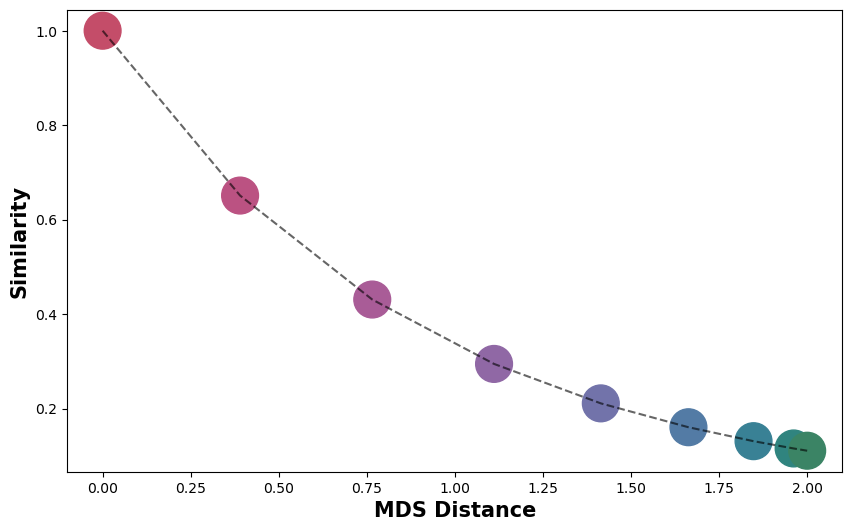

In [ ]:
# Similarity function plot

x = distances[0][:9]
c = 1.1
sim = np.exp(-c * x)

fig, ax = plt.subplots(figsize=(10,6))
ax.plot(x, sim, color="black", linestyle="--", alpha = 0.6)

selected_colors = item_colors[0:9]

ax.scatter(x, sim, color=selected_colors, s=700)

ax.set_xlabel("MDS Distance", fontsize=15, fontweight="bold")
ax.set_ylabel("Similarity", fontsize=15, fontweight="bold")

plt.show()